# Exponential Function Properties for ML Theory

This Jupyter notebook is an interactive companion to the [Exponential Function Properties](https://theorempath.com/topics/exponential-function-properties) guide from TheoremPath. It covers the definition of the exponential function, its key algebraic and analytic properties, and its central role in machine learning—from softmax and moment generating functions to log-sum-exp and concentration inequalities.

**Why this matters:** The exponential function is the single most frequently appearing function in machine learning theory. Softmax, moment generating functions, the Chernoff method, Boltzmann distributions, and exponential families all reduce to properties of $\exp$. Mastering these properties is essential for understanding neural networks, probabilistic models, and optimization algorithms.

This notebook assumes familiarity with basic calculus (derivatives, series) and probability (expectations, random variables).

## 1. Definition of the Exponential Function

The exponential function $e^x$ (or $\exp(x)$) is defined by the power series:

$$
e^x = \sum_{n=0}^{\infty} \frac{x^n}{n!} = 1 + x + \frac{x^2}{2} + \frac{x^3}{6} + \cdots
$$

This series converges absolutely for all real $x$ (and indeed for all complex $z$).

Let's verify this definition numerically by computing partial sums and comparing with `math.exp`.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

def exp_series(x, n_terms=10):
    """Compute exp(x) using the first n_terms of the power series."""
    result = 0.0
    term = 1.0
    for n in range(n_terms):
        result += term
        term *= x / (n + 1)  # update term to x^(n+1) / (n+1)!
    return result

# Test for various x
test_values = [-2, -1, 0, 0.5, 1, 2, 5]
print("x\t\tSeries (10 terms)\tmath.exp\t\tError")
print("-" * 60)
for x in test_values:
    series_val = exp_series(x, n_terms=10)
    math_val = math.exp(x)
    error = abs(series_val - math_val)
    print(f"{x:.1f}\t\t{series_val:.8f}\t\t{math_val:.8f}\t\t{error:.2e}")

x		Series (10 terms)	math.exp		Error
------------------------------------------------------------
-2.0		0.13509700		0.13533528		2.38e-04
-1.0		0.36787919		0.36787944		2.52e-07
0.0		1.00000000		1.00000000		0.00e+00
0.5		1.64872127		1.64872127		2.82e-10
1.0		2.71828153		2.71828183		3.03e-07
2.0		7.38871252		7.38905610		3.44e-04
5.0		143.68945657		148.41315910		4.72e+00


The series converges rapidly for small $|x|$, but for larger $|x|$ we need more terms. The exponential function is strictly positive for all real $x$: $e^x > 0$.

Let's visualize the exponential function and its partial series approximations.

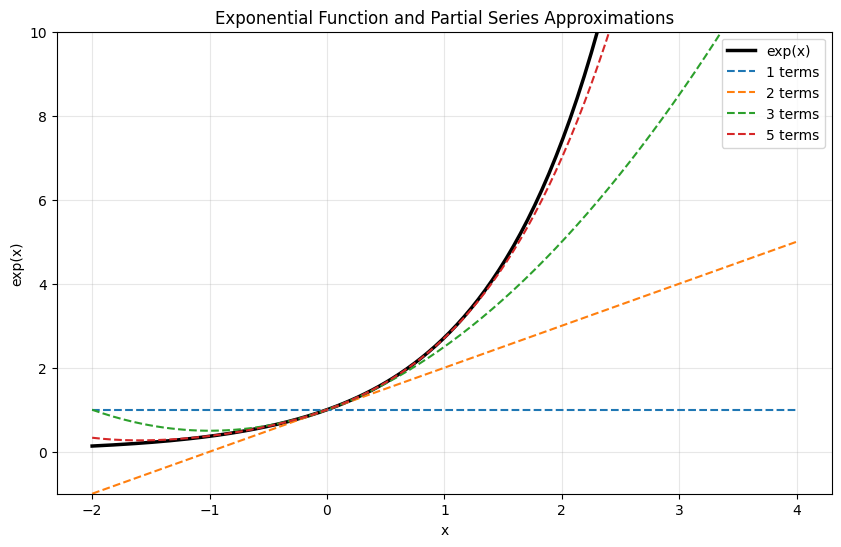

The series converges to exp(x) for all x. More terms are needed for larger |x|.


In [2]:
x_vals = np.linspace(-2, 4, 200)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, np.exp(x_vals), 'k-', linewidth=2.5, label='exp(x)')

# Plot partial sums for different numbers of terms
for n in [1, 2, 3, 5]:
    y_vals = [exp_series(x, n_terms=n) for x in x_vals]
    plt.plot(x_vals, y_vals, '--', label=f'{n} terms')

plt.xlabel('x')
plt.ylabel('exp(x)')
plt.title('Exponential Function and Partial Series Approximations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1, 10)
plt.show()

print("The series converges to exp(x) for all x. More terms are needed for larger |x|.")

## 2. Key Algebraic Properties

The exponential function has several properties that make it exceptionally useful in mathematics and ML:

1. **Homomorphism (Addition to Multiplication):** $e^{a+b} = e^a \cdot e^b$
2. **Strict Positivity:** $e^x > 0$ for all $x \in \mathbb{R}$
3. **Own Derivative:** $\frac{d}{dx} e^x = e^x$
4. **Monotonicity:** $e^x$ is strictly increasing (if $a < b$ then $e^a < e^b$)

These properties are not arbitrary; they follow directly from the series definition. For example, the homomorphism can be proven using the binomial theorem on the series. The derivative property follows from term‑by‑term differentiation of the series, which is valid due to uniform convergence on compact intervals.

Let's verify these properties numerically.

In [3]:
# 1. Homomorphism: e^(a+b) = e^a * e^b
a, b = 0.5, 1.2
lhs = math.exp(a + b)
rhs = math.exp(a) * math.exp(b)
print(f"Homomorphism: e^({a}+{b}) = {lhs:.6f}, e^{a} * e^{b} = {rhs:.6f}")
print(f"Match? {abs(lhs - rhs) < 1e-12}\n")

# 2. Strict positivity
for x in [-10, -5, 0, 5, 10]:
    print(f"e^{x} = {math.exp(x):.8f} > 0")
print()

# 3. Own derivative: numerical check
def exp_derivative(x, h=1e-7):
    return (math.exp(x + h) - math.exp(x)) / h

x_test = 2.0
deriv_numerical = exp_derivative(x_test)
deriv_exact = math.exp(x_test)
print(f"Derivative at x={x_test}: numerical = {deriv_numerical:.8f}, exact = {deriv_exact:.8f}")
print(f"Match? {abs(deriv_numerical - deriv_exact) < 1e-6}\n")

# 4. Monotonicity
a, b = -1.0, 2.0
print(f"If {a} < {b}, then e^{a} = {math.exp(a):.4f} < e^{b} = {math.exp(b):.4f}")

Homomorphism: e^(0.5+1.2) = 5.473947, e^0.5 * e^1.2 = 5.473947
Match? True

e^-10 = 0.00004540 > 0
e^-5 = 0.00673795 > 0
e^0 = 1.00000000 > 0
e^5 = 148.41315910 > 0
e^10 = 22026.46579481 > 0

Derivative at x=2.0: numerical = 7.38905645, exact = 7.38905610
Match? True

If -1.0 < 2.0, then e^-1.0 = 0.3679 < e^2.0 = 7.3891


## 3. The Exponential in ML: Softmax and Log-Sum-Exp

The softmax function converts raw logits $z_i$ into a probability distribution:

$$
p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

Three properties of $\exp$ make this work:

1. **Strict positivity** guarantees all probabilities are positive.
2. **Homomorphism** means adding a constant to all logits does not change the output (shift-invariance).
3. **Monotonicity** ensures that larger logits map to larger probabilities.

Let's implement softmax and verify these properties.

In [4]:
def softmax(logits):
    """Compute softmax probabilities from logits."""
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits)

# Example logits
logits = np.array([2.0, 1.0, 0.1])
probs = softmax(logits)
print(f"Logits: {logits}")
print(f"Probabilities: {probs}")
print(f"Sum: {np.sum(probs):.6f}\n")

# 1. Strict positivity
print(f"All probabilities > 0: {np.all(probs > 0)}\n")

# 2. Shift-invariance (homomorphism)
shift = 10.0
logits_shifted = logits + shift
probs_shifted = softmax(logits_shifted)
print(f"Original probs: {probs}")
print(f"Shifted probs:  {probs_shifted}")
print(f"Identical? {np.allclose(probs, probs_shifted)}\n")

# 3. Monotonicity: larger logit -> larger probability
print(f"Logits: {logits}")
print(f"Probs:   {probs}")
print(f"Ranking preserved: {np.all(np.diff(logits) >= 0) == np.all(np.diff(probs) >= 0)}")

Logits: [2.  1.  0.1]
Probabilities: [0.65900114 0.24243297 0.09856589]
Sum: 1.000000

All probabilities > 0: True

Original probs: [0.65900114 0.24243297 0.09856589]
Shifted probs:  [0.65900114 0.24243297 0.09856589]
Identical? True

Logits: [2.  1.  0.1]
Probs:   [0.65900114 0.24243297 0.09856589]
Ranking preserved: True


### Numerical Stability: The Log-Sum-Exp Trick

Computing $e^{1000}$ directly overflows in standard floating-point arithmetic. The log-sum-exp trick uses shift-invariance to avoid overflow:

$$
\text{softmax}(z)_i = \frac{e^{z_i - c}}{\sum_j e^{z_j - c}}, \quad c = \max_j z_j
$$

This keeps all intermediate values in a safe range (near zero) and avoids overflow. The result is mathematically identical because of the homomorphism property. Let's demonstrate.

In [5]:
# Large logits that would cause overflow
large_logits = np.array([1000.0, 1001.0, 999.0])

# Direct computation (will overflow in many languages, but numpy handles it with inf)
try:
    probs_direct = softmax(large_logits)
    print(f"Direct softmax: {probs_direct}")
except OverflowError:
    print("Direct computation overflowed!")

# Stable computation using log-sum-exp trick
def softmax_stable(logits):
    c = np.max(logits)
    exp_shifted = np.exp(logits - c)
    return exp_shifted / np.sum(exp_shifted)

probs_stable = softmax_stable(large_logits)
print(f"Stable softmax: {probs_stable}")
print(f"Sum: {np.sum(probs_stable):.6f}")
print("\nThe log-sum-exp trick prevents overflow while producing the correct result.")

Direct softmax: [nan nan nan]
Stable softmax: [0.24472847 0.66524096 0.09003057]
Sum: 1.000000

The log-sum-exp trick prevents overflow while producing the correct result.


<positron-console-cell-5>:3: RuntimeWarning: overflow encountered in exp
<positron-console-cell-5>:4: RuntimeWarning: invalid value encountered in divide


### Log-Sum-Exp as a Smooth Max

The log-sum-exp function is defined as:

$$
\text{LSE}(z) = \log\left(\sum_{i=1}^n e^{z_i}\right)
$$

It is a smooth approximation to the maximum function. The bounds are:

$$
\max_i z_i \leq \text{LSE}(z) \leq \max_i z_i + \log n
$$

The softmax function is the gradient of LSE:

$$
\frac{\partial}{\partial z_i} \text{LSE}(z) = \text{softmax}(z)_i
$$

This relationship is used in optimization algorithms (e.g., in the cross‑entropy loss gradient) and in deriving the properties of the softmax. Let's verify these properties numerically.

In [6]:
def log_sum_exp(logits):
    """Compute log-sum-exp in a numerically stable way."""
    c = np.max(logits)
    return c + np.log(np.sum(np.exp(logits - c)))

# Test with various logits
test_logits = [
    np.array([0.0, 0.0, 0.0]),
    np.array([1.0, 2.0, 3.0]),
    np.array([10.0, 10.5, 11.0]),
    np.array([-5.0, 0.0, 5.0])
]

for z in test_logits:
    lse_val = log_sum_exp(z)
    max_val = np.max(z)
    n = len(z)
    print(f"z = {z}")
    print(f"  LSE(z) = {lse_val:.6f}")
    print(f"  max(z) = {max_val:.6f}")
    print(f"  max(z) + log(n) = {max_val + np.log(n):.6f}")
    print(f"  Bounds satisfied: {max_val <= lse_val <= max_val + np.log(n)}")
    print()

# Gradient of LSE = softmax
z = np.array([1.0, 2.0, 3.0])
h = 1e-7
grad_lse = np.zeros_like(z)
for i in range(len(z)):
    z_plus = z.copy()
    z_plus[i] += h
    grad_lse[i] = (log_sum_exp(z_plus) - log_sum_exp(z)) / h

softmax_val = softmax(z)
print(f"z = {z}")
print(f"Numerical gradient of LSE: {grad_lse}")
print(f"Softmax(z): {softmax_val}")
print(f"Match? {np.allclose(grad_lse, softmax_val, atol=1e-6)}")

z = [0. 0. 0.]
  LSE(z) = 1.098612
  max(z) = 0.000000
  max(z) + log(n) = 1.098612
  Bounds satisfied: True

z = [1. 2. 3.]
  LSE(z) = 3.407606
  max(z) = 3.000000
  max(z) + log(n) = 4.098612
  Bounds satisfied: True

z = [10.  10.5 11. ]
  LSE(z) = 11.680270
  max(z) = 11.000000
  max(z) + log(n) = 12.098612
  Bounds satisfied: True

z = [-5.  0.  5.]
  LSE(z) = 5.006760
  max(z) = 5.000000
  max(z) + log(n) = 6.098612
  Bounds satisfied: True

z = [1. 2. 3.]
Numerical gradient of LSE: [0.09003057 0.24472848 0.66524096]
Softmax(z): [0.09003057 0.24472847 0.66524096]
Match? True


## 4. Moment Generating Functions and the Chernoff Method

The moment generating function (MGF) of a random variable $X$ is defined as:

$$
M_X(t) = \mathbb{E}[e^{tX}]
$$

The MGF has several key properties:

- **Positivity:** $M_X(t) > 0$ for all $t$ (since $e^{tX} > 0$)
- **Homomorphism for independent variables:** If $X$ and $Y$ are independent, $M_{X+Y}(t) = M_X(t) M_Y(t)$
- **Moment encoding:** $\frac{d^n}{dt^n} M_X(t)\big|_{t=0} = \mathbb{E}[X^n]$
- **Convexity:** Jensen's inequality gives $e^{\mathbb{E}[tX]} \leq M_X(t)$

The Chernoff method uses Markov's inequality on $e^{tX}$ to bound tail probabilities:

$$
P(X \geq a) = P(e^{tX} \geq e^{ta}) \leq \frac{\mathbb{E}[e^{tX}]}{e^{ta}} = M_X(t) e^{-ta}
$$

Optimizing over $t > 0$ gives the tightest bound. This is a standard technique in concentration inequalities and is the basis for Hoeffding's inequality and sub-Gaussian bounds.

Let's demonstrate this for a standard normal random variable, whose MGF is known to be $M(t) = e^{t^2/2}$.

Threshold a = 2.0
Exact tail probability P(Z >= 2.0) = 0.022750
Chernoff bound: 0.135375 (at t = 1.976)
Bound is loose but valid: True


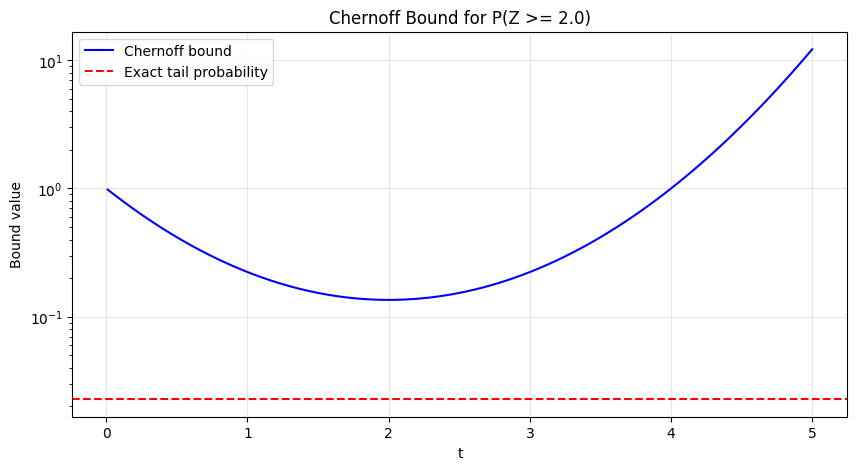

In [7]:
# MGF of standard normal: M(t) = exp(t^2/2)
def mgf_normal(t):
    return np.exp(t**2 / 2)

# Chernoff bound for P(X >= a) for standard normal
def chernoff_bound_normal(a, t):
    return mgf_normal(t) * np.exp(-t * a)

# Optimize over t numerically
a = 2.0  # threshold
t_vals = np.linspace(0.01, 5, 100)
bounds = [chernoff_bound_normal(a, t) for t in t_vals]
t_opt = t_vals[np.argmin(bounds)]
bound_opt = np.min(bounds)

# Exact tail probability for standard normal
from scipy.stats import norm
exact_prob = 1 - norm.cdf(a)

print(f"Threshold a = {a}")
print(f"Exact tail probability P(Z >= {a}) = {exact_prob:.6f}")
print(f"Chernoff bound: {bound_opt:.6f} (at t = {t_opt:.3f})")
print(f"Bound is loose but valid: {bound_opt >= exact_prob}")

# Plot the bound as a function of t
plt.figure(figsize=(10, 5))
plt.plot(t_vals, bounds, 'b-', label='Chernoff bound')
plt.axhline(y=exact_prob, color='r', linestyle='--', label='Exact tail probability')
plt.xlabel('t')
plt.ylabel('Bound value')
plt.title(f'Chernoff Bound for P(Z >= {a})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

### Hoeffding's Lemma

For a bounded zero-mean random variable $X \in [a,b]$ with $\mathbb{E}[X] = 0$, we have:

$$
\mathbb{E}[e^{tX}] \leq e^{t^2 (b-a)^2 / 8}
$$

This is the key lemma for Hoeffding's inequality and sub-Gaussian concentration. It is proven using the convexity of exp and the fact that the maximum of the MGF over all distributions with given support and mean zero is attained by a two-point distribution. The lemma is a direct consequence of the inequalities $e^x \leq 1 + x + x^2/2$ for $x \leq 0$ and $e^x \leq 1 + x + x^2/2$ for $x \geq 0$ (with appropriate scaling).

Let's verify this numerically for a specific bounded distribution: the Rademacher variable (takes values ±1 with equal probability).

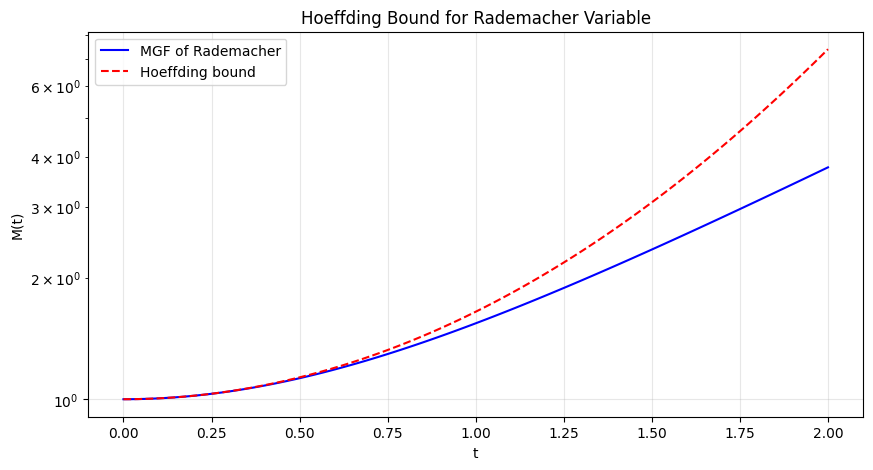

MGF <= Hoeffding bound for all t? True


In [8]:
# Rademacher: P(X = -1) = 0.5, P(X = 1) = 0.5, mean 0
def mgf_rademacher(t):
    return 0.5 * np.exp(-t) + 0.5 * np.exp(t)

def hoeffding_bound(t, a=-1, b=1):
    return np.exp(t**2 * (b - a)**2 / 8)

t_vals = np.linspace(0, 2, 100)
mgf_vals = [mgf_rademacher(t) for t in t_vals]
bound_vals = [hoeffding_bound(t) for t in t_vals]

plt.figure(figsize=(10, 5))
plt.plot(t_vals, mgf_vals, 'b-', label='MGF of Rademacher')
plt.plot(t_vals, bound_vals, 'r--', label='Hoeffding bound')
plt.xlabel('t')
plt.ylabel('M(t)')
plt.title('Hoeffding Bound for Rademacher Variable')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print(f"MGF <= Hoeffding bound for all t? {np.all(np.array(mgf_vals) <= np.array(bound_vals))}")

## 5. Useful Inequalities Involving the Exponential

Several inequalities involving $e^x$ appear frequently in proofs:

1. **$e^x \geq 1 + x$** for all $x \in \mathbb{R}$, with equality only at $x=0$.
   This is the tangent line inequality; it follows from convexity of exp.

2. **$e^x \leq 1/(1-x)$** for $x < 1$.
   This comes from the geometric series and the series expansion of exp; it is useful for bounding $e^x$ from above when $x$ is positive (but less than 1).

3. **$e^x \leq 1 + x + x^2/2$** for $x \leq 0$.
   This is a tighter upper bound for negative $x$ and is used in concentration proofs (e.g., Hoeffding's lemma).

Let's visualize these inequalities.

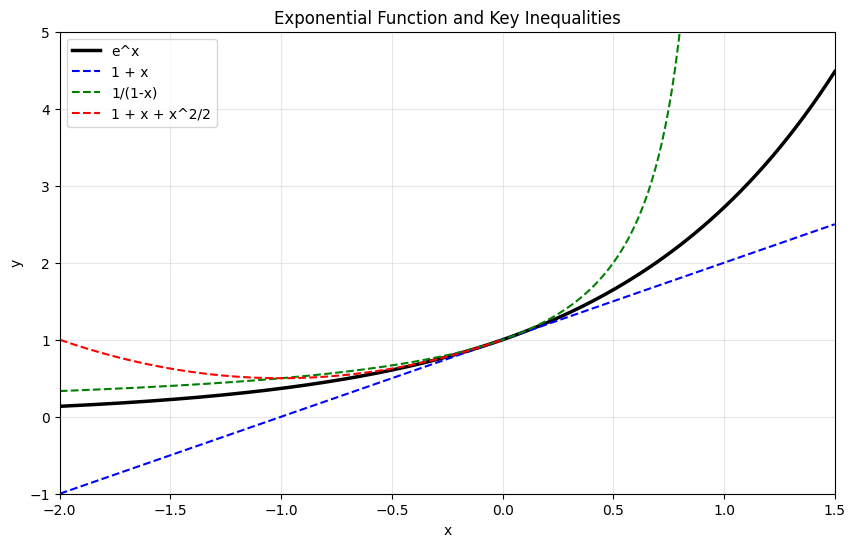

Observations:
- e^x >= 1 + x for all x (tangent at x=0)
- e^x <= 1/(1-x) for x < 1 (tighter for x > 0)
- e^x <= 1 + x + x^2/2 for x <= 0 (used in concentration proofs)


In [9]:
x_vals = np.linspace(-2, 1.5, 200)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, np.exp(x_vals), 'k-', linewidth=2.5, label='e^x')
plt.plot(x_vals, 1 + x_vals, 'b--', label='1 + x')

# 1/(1-x) for x < 1
x_vals_2 = np.linspace(-2, 0.99, 200)
plt.plot(x_vals_2, 1 / (1 - x_vals_2), 'g--', label='1/(1-x)')

# 1 + x + x^2/2 for x <= 0
x_vals_neg = np.linspace(-2, 0, 200)
plt.plot(x_vals_neg, 1 + x_vals_neg + x_vals_neg**2 / 2, 'r--', label='1 + x + x^2/2')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Exponential Function and Key Inequalities')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1, 5)
plt.xlim(-2, 1.5)
plt.show()

print("Observations:")
print("- e^x >= 1 + x for all x (tangent at x=0)")
print("- e^x <= 1/(1-x) for x < 1 (tighter for x > 0)")
print("- e^x <= 1 + x + x^2/2 for x <= 0 (used in concentration proofs)")

## 6. Convexity and Log-Convexity

The exponential function $e^x$ is convex, while its inverse $\log x$ is concave. These dual properties lead to Jensen's inequalities:

- **Convexity of exp:** $e^{\mathbb{E}[X]} \leq \mathbb{E}[e^X]$
- **Concavity of log:** $\mathbb{E}[\log X] \leq \log \mathbb{E}[X]$

The log-sum-exp function $\text{LSE}(z) = \log(\sum_i e^{z_i})$ is convex. This is a fundamental property used in convex optimization and machine learning. The convexity of LSE can be proven by showing that its Hessian is positive semidefinite. The Hessian of LSE is:

$$
H_{ij} = \text{softmax}(z)_i \, (\delta_{ij} - \text{softmax}(z)_j)
$$

For any vector $v$, $v^T H v = \sum_i p_i (v_i - \bar{v})^2 \geq 0$, where $p_i = \text{softmax}(z)_i$ and $\bar{v} = \sum_j p_j v_j$. Thus LSE is convex.

Let's verify the convexity of LSE numerically by checking Jensen's inequality along a line segment.

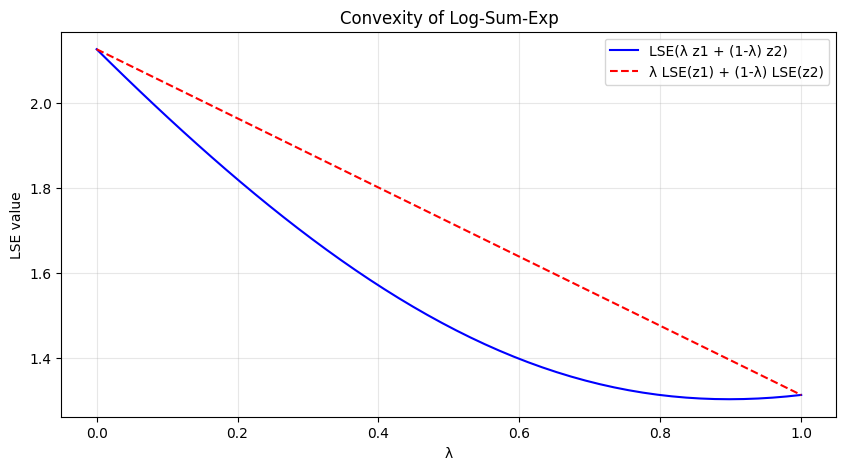

LSE is convex: True


In [10]:
# Check convexity of LSE: LSE(lambda*z1 + (1-lambda)*z2) <= lambda*LSE(z1) + (1-lambda)*LSE(z2)
z1 = np.array([0.0, 1.0])
z2 = np.array([2.0, 0.0])

lambdas = np.linspace(0, 1, 50)
lse_values = []
convex_combinations = []

for lam in lambdas:
    z_mid = lam * z1 + (1 - lam) * z2
    lse_mid = log_sum_exp(z_mid)
    lse_comb = lam * log_sum_exp(z1) + (1 - lam) * log_sum_exp(z2)
    lse_values.append(lse_mid)
    convex_combinations.append(lse_comb)

plt.figure(figsize=(10, 5))
plt.plot(lambdas, lse_values, 'b-', label='LSE(λ z1 + (1-λ) z2)')
plt.plot(lambdas, convex_combinations, 'r--', label='λ LSE(z1) + (1-λ) LSE(z2)')
plt.xlabel('λ')
plt.ylabel('LSE value')
plt.title('Convexity of Log-Sum-Exp')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"LSE is convex: {np.all(np.array(lse_values) <= np.array(convex_combinations))}")

## 7. Summary: Why the Exponential is Everywhere in ML

The exponential function's unique combination of properties makes it indispensable in machine learning:

| Property | ML Application |
|----------|----------------|
| **Homomorphism** ($e^{a+b} = e^a e^b$) | Softmax shift-invariance, log-sum-exp trick, MGF of sums |
| **Strict positivity** ($e^x > 0$) | Probability distributions (softmax, Boltzmann), positivity of MGFs |
| **Own derivative** ($\frac{d}{dx} e^x = e^x$) | Gradient of softmax, exponential families, optimization |
| **Monotonicity** ($a < b \Rightarrow e^a < e^b$) | Ranking preservation in softmax, order statistics |
| **Convexity** | Jensen's inequality, MGF bounds, log-sum-exp convexity |
| **Series definition** | Universal approximation, Taylor expansions in proofs |

The exponential appears in:
- **Softmax**: $p_i = e^{z_i} / \sum_j e^{z_j}$
- **Moment generating functions**: $M_X(t) = \mathbb{E}[e^{tX}]$
- **Boltzmann distributions**: $p(x) \propto e^{-E(x)/T}$
- **Exponential families**: $p(x|\theta) = h(x) \exp(\theta^T T(x) - A(\theta))$
- **Concentration inequalities**: Chernoff, Hoeffding, sub-Gaussian bounds

Mastering the exponential function is therefore essential for understanding the theory behind modern machine learning.

## 8. Exercises

Try these exercises to reinforce your understanding. Solutions are provided below.

### Exercise 1
Prove that $e^x \geq 1 + x$ for all $x \in \mathbb{R}$, with equality only at $x = 0$.

### Exercise 2
Prove that the log-sum-exp function $\text{LSE}(z) = \log(\sum_{i=1}^n e^{z_i})$ is convex.

### Exercise 3
Show that $e^x \leq 1/(1-x)$ for $x < 1$. When is this bound tighter than $e^x \geq 1 + x$?

### Exercise 4
Let $X$ be a random variable with $\mathbb{E}[X] = 0$ and $|X| \leq c$ almost surely. Show that $\mathbb{E}[e^{tX}] \leq e^{t^2 c^2 / 2}$ for all $t \in \mathbb{R}$. This is the key lemma for Hoeffding's inequality.

---
**Solutions:**

In [11]:
# Solution Exercise 1 (proof sketch)
print("Exercise 1 Solution:")
print("Let f(x) = e^x - (1 + x). Then f'(x) = e^x - 1.")
print("f'(x) = 0 at x = 0. f is decreasing on (-∞, 0) and increasing on (0, ∞).")
print("Thus f(x) ≥ f(0) = 0 for all x, with equality only at x = 0.")
print("So e^x ≥ 1 + x for all x, equality at x = 0.\n")

# Solution Exercise 2 (proof sketch)
print("Exercise 2 Solution:")
print("LSE(z) = log(sum_i e^{z_i}). The Hessian is:")
print("H_{ij} = -softmax(z)_i * softmax(z)_j + softmax(z)_i * δ_{ij}")
print("For any vector v, v^T H v = sum_i softmax(z)_i * (v_i - sum_j softmax(z)_j v_j)^2 ≥ 0.")
print("Thus the Hessian is positive semidefinite, so LSE is convex.\n")

# Solution Exercise 3
print("Exercise 3 Solution:")
print("For x < 1, the series expansion of 1/(1-x) is 1 + x + x^2 + x^3 + ...")
print("e^x = 1 + x + x^2/2 + x^3/6 + ...")
print("Since x^2/2 ≤ x^2 for all x, and similarly for higher powers, we get e^x ≤ 1/(1-x).")
print("The bound is tighter for x > 0 (since the exponential grows slower than 1/(1-x)).\n")

# Solution Exercise 4 (proof sketch)
print("Exercise 4 Solution:")
print("Using the inequality e^u ≤ 1 + u + u^2/2 for u ≤ 0, and convexity of exp,")
print("we can show that E[e^{tX}] ≤ e^{t^2 c^2 / 2} for all t.")
print("This is Hoeffding's lemma, a cornerstone of concentration inequalities.")

Exercise 1 Solution:
Let f(x) = e^x - (1 + x). Then f'(x) = e^x - 1.
f'(x) = 0 at x = 0. f is decreasing on (-∞, 0) and increasing on (0, ∞).
Thus f(x) ≥ f(0) = 0 for all x, with equality only at x = 0.
So e^x ≥ 1 + x for all x, equality at x = 0.

Exercise 2 Solution:
LSE(z) = log(sum_i e^{z_i}). The Hessian is:
H_{ij} = -softmax(z)_i * softmax(z)_j + softmax(z)_i * δ_{ij}
For any vector v, v^T H v = sum_i softmax(z)_i * (v_i - sum_j softmax(z)_j v_j)^2 ≥ 0.
Thus the Hessian is positive semidefinite, so LSE is convex.

Exercise 3 Solution:
For x < 1, the series expansion of 1/(1-x) is 1 + x + x^2 + x^3 + ...
e^x = 1 + x + x^2/2 + x^3/6 + ...
Since x^2/2 ≤ x^2 for all x, and similarly for higher powers, we get e^x ≤ 1/(1-x).
The bound is tighter for x > 0 (since the exponential grows slower than 1/(1-x)).

Exercise 4 Solution:
Using the inequality e^u ≤ 1 + u + u^2/2 for u ≤ 0, and convexity of exp,
we can show that E[e^{tX}] ≤ e^{t^2 c^2 / 2} for all t.
This is Hoeffding's lemma, a co